# Más hoja verde, menos aves

China empujó los paneles solares con políticas de provincia, de municipio y de condado. Donde ese empuje fue más fuerte pasaron dos cosas al tiempo: el suelo quedó más frondoso y la diversidad de aves cayó.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

Vamos a rehacer las regresiones del paper desde su propio paquete de réplica: 46.371 observaciones de 2.344 condados chinos, mes a mes, entre 2014 y 2023.

**Paper:** Zhang et al. (2026). *China's solar expansion policy reduces bird diversity*. Science.
**DOI:** [10.1126/science.aee0747](https://doi.org/10.1126/science.aee0747)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-20-solar-china-aves-diversidad/notebook.ipynb)

**Video:** [Pendiente]

## Dos números por condado y por mes

Un condado chino cualquiera, un mes cualquiera. Alguien sale con binoculares, anota qué pájaros ve y sube la lista a una base de ciencia ciudadana. De ahí sale el **índice de Shannon**: sube cuando hay muchas especies y ninguna manda sobre las demás, baja cuando quedan cuatro o cinco repartiéndose el barrio.

Al otro lado está el **PSI** (*Policy Stringency Index*, índice de rigor de política fotovoltaica): cuánto empujaron los paneles ese condado, su municipio y su provincia, sumados con pesos. Va de 0 a 15,5 y casi seis de cada diez condados-mes están en cero (59,2 por ciento) — nunca les tocó una política.

La pregunta es qué le pasa a las aves de un condado cuando su PSI sube. El truco del diseño está en los **efectos fijos**: al absorber un promedio propio por condado y otro por mes, cada condado termina comparado contra sí mismo en otro momento, no contra un condado vecino más rico o más seco. Aun así es un panel observacional, no un experimento: nadie sorteó qué condado recibía política.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
VARIABLE_POLITICA = 'PI'          # PSI: rigor de política fotovoltaica (0 a 15,5)
VARIABLE_AVES     = 'ShannonBD'   # índice de Shannon de la comunidad de aves
CONTROLES = ['Temp', 'Wind', 'Pop', 'Duration', 'Carbon',
             'Water', 'Green', 'Farm', 'Grass']

FUENTE = ('Fuente: Zhang et al. (2026), Science  |  '
          'Datos: paquete de réplica de los autores (GitHub)')
COLOR_DATOS      = '#2563EB'   # azul CaM — efecto principal
COLOR_ALERTA     = '#DC2626'   # rojo — el valor que contrasta
COLOR_SECUNDARIO = '#059669'   # verde
COLOR_REFERENCIA = '#D97706'   # ámbar — la anomalía
COLOR_NULO       = '#BBBBBB'   # gris — sin señal estadística

# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
SLUG = '2026-08-20-solar-china-aves-diversidad'

# Estilo editorial del canal (local → GitHub como respaldo)
estilo = '../../cam.mplstyle'
if not os.path.exists(estilo):
    estilo = '/tmp/cam.mplstyle'
    if not os.path.exists(estilo):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', estilo)
plt.style.use(estilo)

# Datos (los descarga solo si corres esto fuera del repo, p. ej. en Colab)
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for archivo in ('panel_base.csv', 'panel_rasgos.csv'):
    if not os.path.exists(f'datos/{archivo}'):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{archivo}',
                                   f'datos/{archivo}')

base   = pd.read_csv('datos/panel_base.csv')
rasgos = pd.read_csv('datos/panel_rasgos.csv')
d = base.merge(rasgos, on=['id', 'ym'], how='left')

print(f'Panel: {len(d):,} filas · {d.id.nunique():,} condados · {d.ym.nunique()} meses'
      .replace(',', '.'))
print(f'Periodo: {d.ym.min()} a {d.ym.max()}')
print(f'Shannon  → media {d.ShannonBD.mean():.4f}   DE {d.ShannonBD.std(ddof=1):.4f}')
print(f'PSI      → media {d.PI.mean():.4f}   DE {d.PI.std(ddof=1):.4f}   máx {d.PI.max()}')
print(f'Condados-mes con alguna política vigente: {(d.PI > 0).sum():,} '
      f'({100 * (d.PI > 0).mean():.1f} por ciento)'.replace(',', '.'))


def coma_decimal(ax, ejes='xy', decimales=2):
    """En español los decimales van con coma; matplotlib los pinta con punto."""
    from matplotlib.ticker import FuncFormatter
    fmt = FuncFormatter(lambda v, _: f'{v:,.{decimales}f}'
                        .replace(',', '@').replace('.', ',').replace('@', '.'))
    if 'x' in ejes:
        ax.xaxis.set_major_formatter(fmt)
    if 'y' in ejes:
        ax.yaxis.set_major_formatter(fmt)

Panel: 46.371 filas · 2.344 condados · 120 meses
Periodo: 201401 a 202312
Shannon  → media 2.4478   DE 0.9810
PSI      → media 2.6576   DE 4.1152   máx 15.5
Condados-mes con alguna política vigente: 18.909 (40.8 por ciento)


### El estimador, escrito a mano

El paper corre `reghdfe` en Stata: mínimos cuadrados con efectos fijos de condado y de mes, y errores estándar agrupados por condado. Lo reescribimos en numpy para que el notebook no dependa de Stata ni de librerías econométricas — son treinta líneas, y hay dos detalles que deciden si los números cuadran o no:

1. **Los condados con una sola observación se van.** No aportan variación interna; su efecto fijo se come la fila completa. `reghdfe` los descarta en cascada (quitar unos puede dejar a otros solos). Al construir estos CSV ese paso quitó 157 filas y dejó el panel en 46.371 — justo el N del paper —, así que los archivos que descargas ya vienen limpios y la función no tiene nada que quitar en la regresión principal. Donde sí actúa es en las variables con datos faltantes: la riqueza, por ejemplo, se queda en 45.606 filas y 2.315 condados.
2. **Los efectos fijos de condado no cuentan como parámetros** en la corrección de muestra finita, porque están anidados dentro del clúster de condado. Contarlos infla los errores estándar como un 3 por ciento y ya no coinciden con la tabla publicada.

In [2]:
def _absorber(M, c1, n1, c2, n2, tol=1e-11, max_iter=300):
    """Quita los dos efectos fijos por proyecciones alternadas (converge en ~15 vueltas)."""
    M = M.copy()
    for _ in range(max_iter):
        previo = M.copy()
        for codigos, n in ((c1, n1), (c2, n2)):
            cuenta = np.bincount(codigos, minlength=n).astype(float)
            for j in range(M.shape[1]):
                suma = np.bincount(codigos, weights=M[:, j], minlength=n)
                M[:, j] -= (suma / cuenta)[codigos]
        if np.max(np.abs(M - previo)) < tol:
            break
    return M


def _quitar_singletons(sub):
    """Detalle 1: descarte en cascada de grupos con una sola observación."""
    while True:
        n0 = len(sub)
        for llave in ('id', 'ym'):
            codigos = pd.factorize(sub[llave].to_numpy())[0]
            sub = sub[np.bincount(codigos)[codigos] > 1]
        if len(sub) == n0:
            return sub


def regresion(datos, y, x=VARIABLE_POLITICA, controles=CONTROLES):
    """Efectos fijos de condado y mes, errores estándar agrupados por condado."""
    cols = [x] + list(controles)
    sub = _quitar_singletons(datos.dropna(subset=[y] + cols))
    c1, u1 = pd.factorize(sub['id'].to_numpy())
    c2, u2 = pd.factorize(sub['ym'].to_numpy())
    M = _absorber(sub[[y] + cols].to_numpy(float), c1, len(u1), c2, len(u2))
    Y, X = M[:, 0], M[:, 1:]
    XtXi = np.linalg.inv(X.T @ X)
    beta = XtXi @ (X.T @ Y)
    resid = Y - X @ beta

    # La "carne" del sándwich agrupado (en inglés, meat): suma de puntajes por condado
    puntajes = np.zeros((len(u1), X.shape[1]))
    np.add.at(puntajes, c1, X * resid[:, None])

    G, N = len(u1), len(sub)
    K = X.shape[1] + len(u2)          # detalle 2: los FE de condado NO suman aquí
    ajuste = (G / (G - 1)) * ((N - 1) / (N - K))
    V = ajuste * XtXi @ (puntajes.T @ puntajes) @ XtXi

    b, ee = beta[0], float(np.sqrt(np.diag(V))[0])
    t = b / ee
    p = 2 * stats.t.sf(abs(t), G - 1)
    return {'b': float(b), 'ee': ee, 't': float(t), 'p': float(p), 'N': N,
            'condados': G, 'sd_y': float(sub[y].std(ddof=1)),
            'ic_bajo': float(b - 1.96 * ee), 'ic_alto': float(b + 1.96 * ee),
            'estrellas': '***' if p < .01 else '**' if p < .05 else '*' if p < .1 else 'ns'}


# Especificación central del paper (Tabla 1, columna 3)
principal = regresion(d, VARIABLE_AVES)
SD_PSI = d.PI.std(ddof=1)

print(f"β(PSI → Shannon) = {principal['b']:.4f}   "
      f"EE {principal['ee']:.4f}   t {principal['t']:.2f}   "
      f"p {principal['p']:.4f} {principal['estrellas']}")
print(f"N = {principal['N']:,}".replace(',', '.') +
      f" · condados = {principal['condados']:,}".replace(',', '.'))
print(f"Publicado en el paper: β −0,0125 · EE 0,0037 · N 46.371 · 2.344 condados")

β(PSI → Shannon) = -0.0125   EE 0.0037   t -3.43   p 0.0006 ***
N = 46.371 · condados = 2.344
Publicado en el paper: β −0,0125 · EE 0,0037 · N 46.371 · 2.344 condados


Cuadró al cuarto decimal. Ahora partamos ese promedio por tipo de condado.

Aquí está.

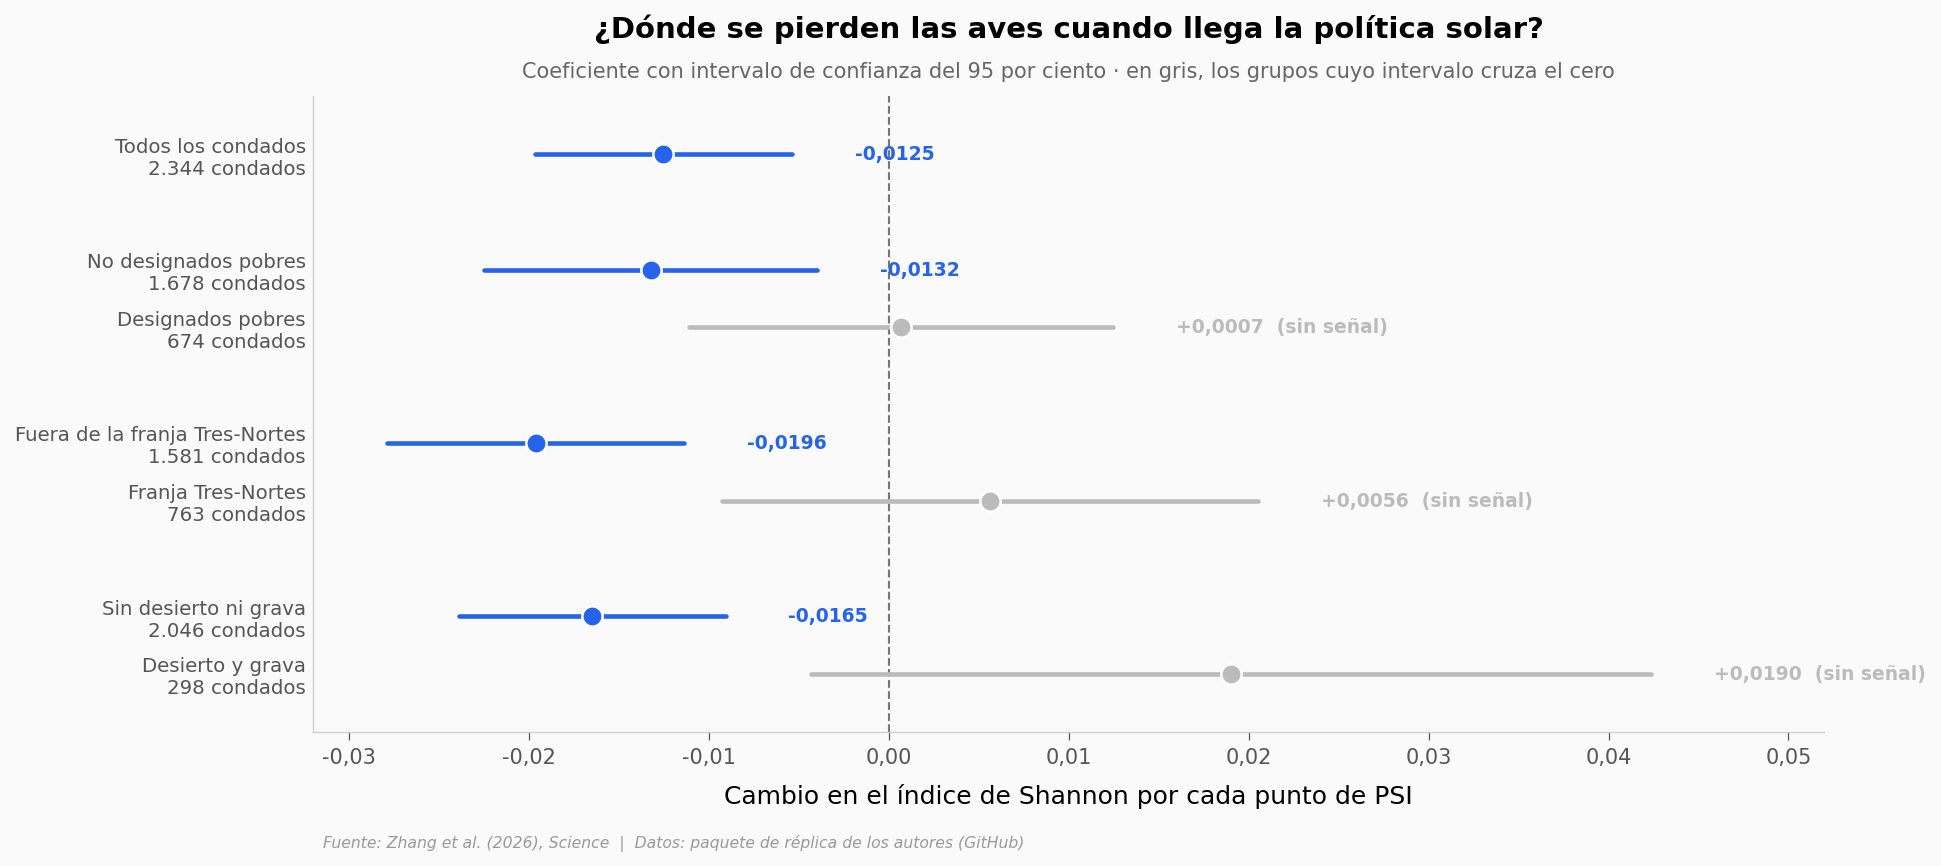

Todos los condados                 β -0.0125  EE 0.0037  p 0.001 ***  N 46.371
No designados pobres               β -0.0132  EE 0.0047  p 0.005 ***  N 37.665
Designados pobres                  β +0.0007  EE 0.0060  p 0.911  ns  N 8.704
Fuera de la franja Tres-Nortes     β -0.0196  EE 0.0042  p 0.000 ***  N 34.829
Franja Tres-Nortes                 β +0.0056  EE 0.0076  p 0.461  ns  N 11.542
Sin desierto ni grava              β -0.0165  EE 0.0038  p 0.000 ***  N 41.355
Desierto y grava                   β +0.0190  EE 0.0119  p 0.112  ns  N 5.016


In [3]:
grupos = [
    ('Todos los condados',              d,                        None),
    ('No designados pobres',            d[d.poverty_county == 0],  None),
    ('Designados pobres',               d[d.poverty_county == 1],  None),
    ('Fuera de la franja Tres-Nortes',  d[d.north_region == 0],    None),
    ('Franja Tres-Nortes',              d[d.north_region == 1],    None),
    ('Sin desierto ni grava',           d[d.desert_gobi == 0],     None),
    ('Desierto y grava',                d[d.desert_gobi == 1],     None),
]
het = [(nombre, regresion(sub, VARIABLE_AVES)) for nombre, sub, _ in grupos]

fig, ax = plt.subplots(figsize=(13, 5.5))
posiciones = [6, 4.6, 3.9, 2.5, 1.8, 0.4, -0.3]   # gap entre pares

for pos, (nombre, r) in zip(posiciones, het):
    color = COLOR_DATOS if r['p'] < 0.05 else COLOR_NULO
    ax.plot([r['ic_bajo'], r['ic_alto']], [pos, pos],
            color=color, linewidth=2.2, solid_capstyle='round', zorder=4)
    ax.scatter([r['b']], [pos], color=color, s=95, zorder=5,
               edgecolors='white', linewidths=1.2)
    etiqueta = (f"{r['b']:+.4f}".replace('.', ',') +
                ('' if r['p'] < 0.05 else '  (sin señal)'))
    ax.text(r['ic_alto'] + 0.0035, pos, etiqueta, va='center', fontsize=9,
            color=color, fontweight='bold')

ax.axvline(0, color='#555555', linewidth=1.0, linestyle='--', alpha=0.8, zorder=2)
ax.set_yticks(posiciones)
ax.set_yticklabels([f"{n}\n{r['condados']:,} condados".replace(',', '.')
                    for n, r in het], fontsize=9.5)
ax.set_ylim(-1.0, 6.7)
ax.set_xlim(-0.032, 0.052)
ax.set_xlabel('Cambio en el índice de Shannon por cada punto de PSI')
ax.set_title('¿Dónde se pierden las aves cuando llega la política solar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Coeficiente con intervalo de confianza del 95 por ciento · '
                   'en gris, los grupos cuyo intervalo cruza el cero',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(axis='y', visible=False)
coma_decimal(ax, 'x')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/heterogeneidad.png', dpi=200, bbox_inches='tight')
plt.show()

for nombre, r in het:
    print(f"{nombre:34s} β {r['b']:+.4f}  EE {r['ee']:.4f}  "
          f"p {r['p']:.3f} {r['estrellas']:>3}  N {r['N']:,}".replace(',', '.'))

### Lo que dice esa fila de puntos

El promedio general es real pero pequeño: −0,0125 puntos de Shannon por cada punto de PSI. Como el PSI tiene una desviación estándar de 4,12 puntos, un condado que se mueve una desviación entera pierde unos 0,05 puntos de Shannon — un 5 por ciento de la variación típica del índice. No es una catástrofe visible desde la ventana.

Lo interesante es que ese promedio esconde un reparto muy desigual. Donde hay algo que perder —condados sin la designación oficial de pobreza, fuera del desierto, fuera del cinturón de reforestación de los Tres-Nortes— el coeficiente es más grande y el intervalo se despega del cero. En el desierto y en los condados pobres el intervalo lo cruza de lado a lado.

Cuidado con leer eso como "en el desierto no pasa nada". Un intervalo que cruza el cero significa que estos datos no distinguen el efecto de la ausencia de efecto, y el submuestreo del desierto es chico: 298 condados contra 2.046. Lo que sí se puede decir es que el hallazgo del paper se sostiene donde el paisaje tenía complejidad que perder — que es, palabra por palabra, el argumento de los autores.

## La paradoja: el suelo se puso más verde

Si un condado convierte cultivos y pastizales en instalación solar, uno esperaría ver el paisaje más pelado. Los autores midieron tres cosas del suelo con la misma regresión — verdor por satélite (NDVI), luz nocturna, e índice de área foliar (LAI, cuántos metros cuadrados de hoja hay por metro cuadrado de suelo) — y una de las tres se les fue para el otro lado.

Para poder comparar variables con unidades distintas, cada efecto está en desviaciones estándar de su propia variable, por cada desviación estándar de PSI.

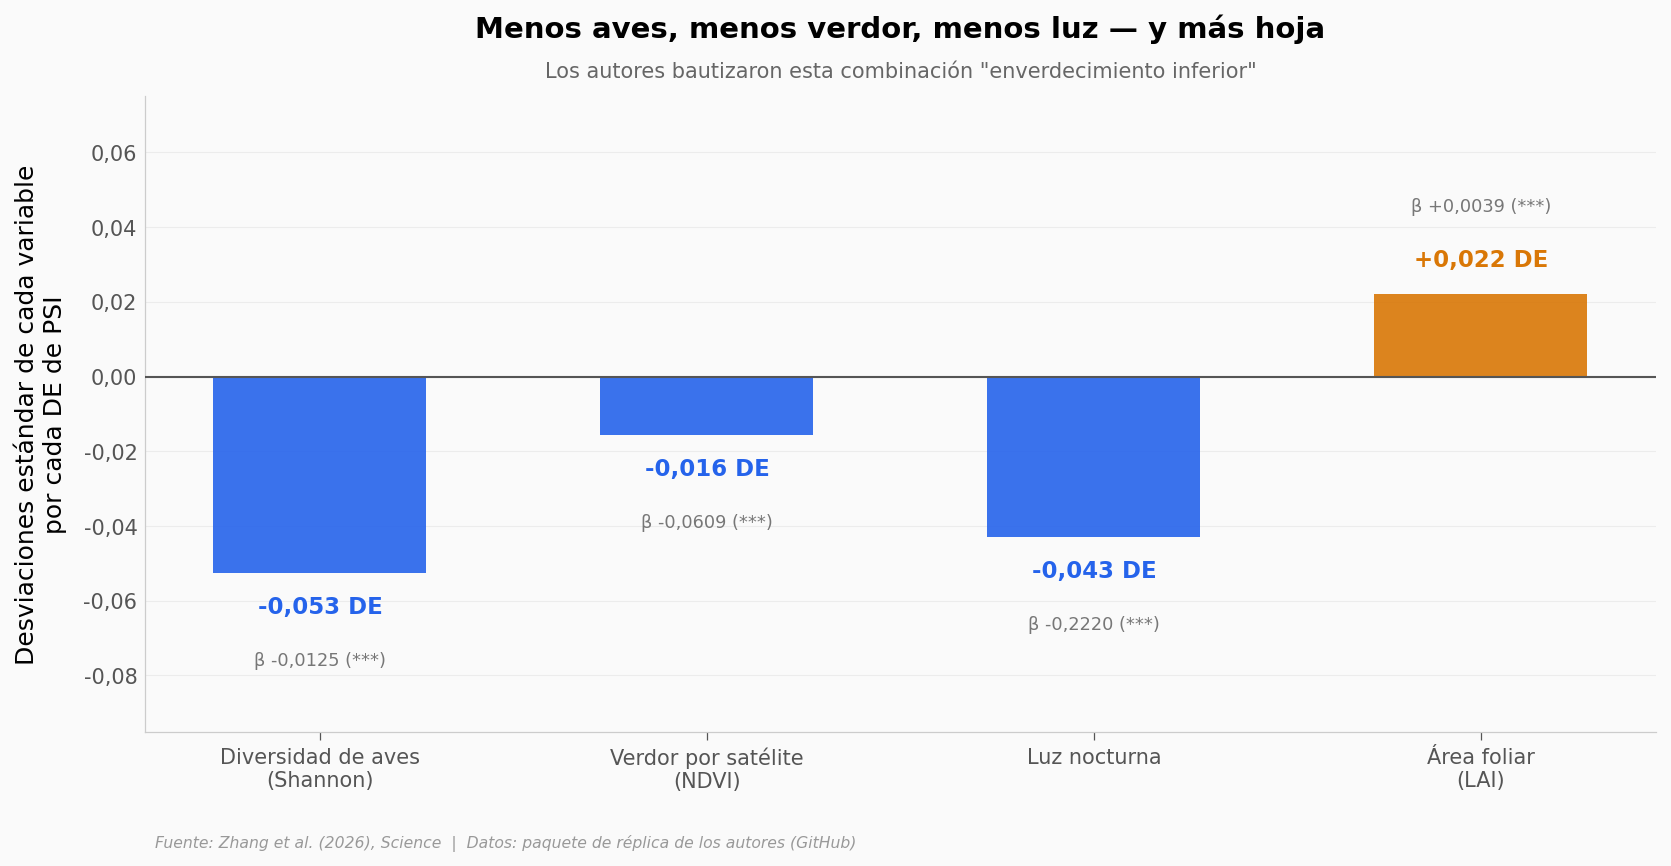

Diversidad de aves (Shannon)           β -0.0125  EE 0.0037  p 0.0006 ***  N 46.371
Verdor por satélite (NDVI)             β -0.0609  EE 0.0138  p 0.0000 ***  N 46.371
Luz nocturna                           β -0.2220  EE 0.0256  p 0.0000 ***  N 46.371
Área foliar (LAI)                      β +0.0039  EE 0.0007  p 0.0000 ***  N 46.338


In [4]:
mecanismo = [
    ('Diversidad de aves\n(Shannon)',      'ShannonBD',  COLOR_DATOS),
    ('Verdor por satélite\n(NDVI)',        'Ndvi',       COLOR_DATOS),
    ('Luz nocturna',                        'Nightlight', COLOR_DATOS),
    ('Área foliar\n(LAI)',                 'LAI',        COLOR_REFERENCIA),
]
mec = [(nombre, regresion(d, col), color) for nombre, col, color in mecanismo]

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(mec))
alturas = [r['b'] * SD_PSI / r['sd_y'] for _, r, _ in mec]
colores = [c for _, _, c in mec]

ax.bar(x, alturas, color=colores, width=0.55, alpha=0.9, zorder=4)
ax.axhline(0, color='#555555', linewidth=1.0, zorder=5)

for xi, altura, (_, r, color) in zip(x, alturas, mec):
    arriba = altura > 0
    ax.text(xi, altura + (0.006 if arriba else -0.006),
            f"{altura:+.3f} DE".replace('.', ','),
            ha='center', va='bottom' if arriba else 'top',
            fontsize=11, fontweight='bold', color=color)
    ax.text(xi, altura + (0.021 if arriba else -0.021),
            f"β {r['b']:+.4f}".replace('.', ',') + f" ({r['estrellas']})",
            ha='center', va='bottom' if arriba else 'top',
            fontsize=8.5, color='#777777')

ax.set_xticks(x)
ax.set_xticklabels([n for n, _, _ in mec], fontsize=10)
ax.set_ylim(-0.095, 0.075)
ax.set_ylabel('Desviaciones estándar de cada variable\npor cada DE de PSI')
ax.set_title('Menos aves, menos verdor, menos luz — y más hoja',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Los autores bautizaron esta combinación "enverdecimiento inferior"',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(axis='x', visible=False)
coma_decimal(ax, 'y')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/paradoja_verde.png', dpi=200, bbox_inches='tight')
plt.show()

for nombre, r, _ in mec:
    print(f"{nombre.replace(chr(10), ' '):38s} β {r['b']:+.4f}  EE {r['ee']:.4f}  "
          f"p {r['p']:.4f} {r['estrellas']:>3}  N {r['N']:,}".replace(',', '.'))

### Qué es y qué no es "enverdecimiento inferior"

El término lo acuñaron los autores en este mismo paper: no es vocabulario establecido de la ecología. Nombra el patrón de arriba — más hoja por metro cuadrado, menos verdor y menos diversidad de aves — y la idea es que un paisaje variado se reemplaza por vegetación densa pero toda igual.

Dos cosas que no vamos a estirar. El abstract dice que el mecanismo es la conversión de cultivos y pastizales en suelo desarrollado; **esa regresión no viene en el paquete de réplica**, así que aquí no la reprodujimos y no la damos por reproducida. Y la luz nocturna baja, cuando "suelo desarrollado" sugeriría lo contrario: reportamos el signo sin inventarle una explicación, porque el material accesible no la da.

Sigamos con lo que sí está en los datos: a qué aves les tocó.

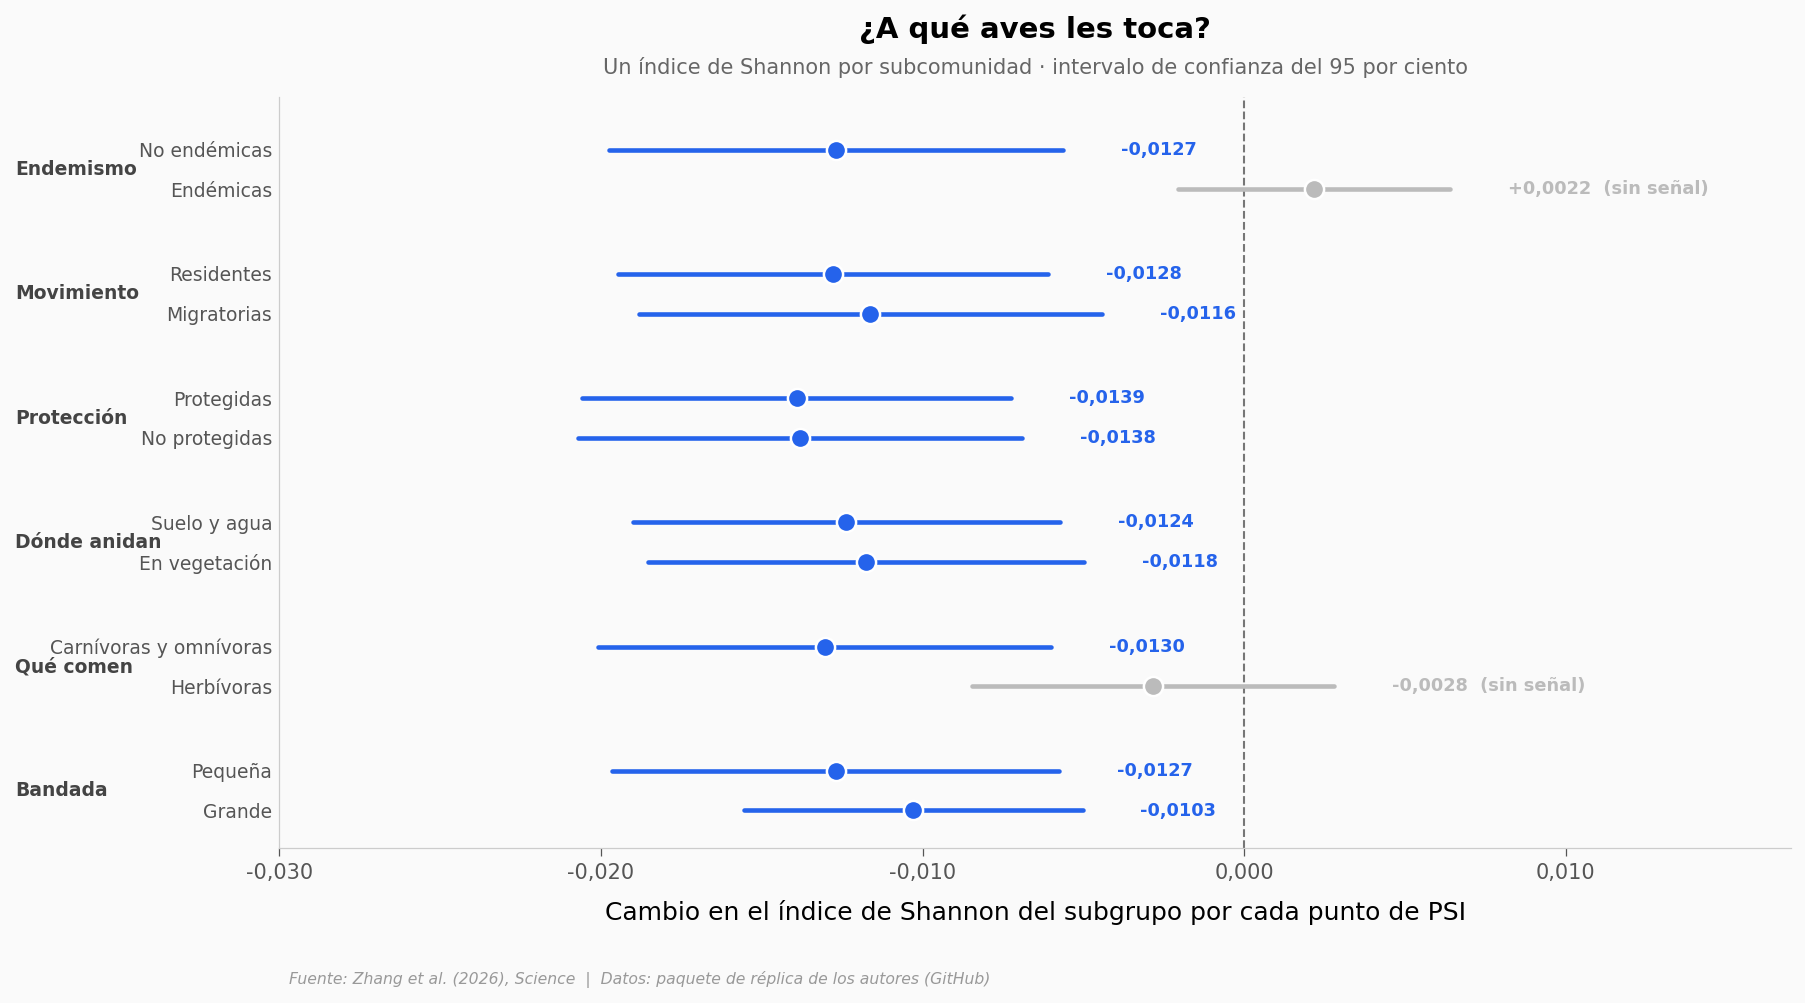

Endemismo      No endémicas             β -0.0127  EE 0.0036  p 0.0004 ***  N 46.217
Endemismo      Endémicas                β +0.0022  EE 0.0022  p 0.3151  ns  N 24.581


Movimiento     Residentes               β -0.0128  EE 0.0034  p 0.0002 ***  N 45.469
Movimiento     Migratorias              β -0.0116  EE 0.0037  p 0.0016 ***  N 39.837


Protección     Protegidas               β -0.0139  EE 0.0034  p 0.0000 ***  N 33.562
Protección     No protegidas            β -0.0138  EE 0.0035  p 0.0001 ***  N 45.666


Dónde anidan   Suelo y agua             β -0.0124  EE 0.0034  p 0.0003 ***  N 43.999
Dónde anidan   En vegetación            β -0.0118  EE 0.0035  p 0.0007 ***  N 44.779


Qué comen      Carnívoras y omnívoras   β -0.0130  EE 0.0036  p 0.0003 ***  N 46.259
Qué comen      Herbívoras               β -0.0028  EE 0.0029  p 0.3256  ns  N 9.765
Bandada        Pequeña                  β -0.0127  EE 0.0035  p 0.0003 ***  N 46.045


Bandada        Grande                   β -0.0103  EE 0.0027  p 0.0001 ***  N 38.658


In [5]:
pares = [
    ('Endemismo',   ('No endémicas', 'non_Endemic'), ('Endémicas', 'Endemic')),
    ('Movimiento',  ('Residentes', 'Resident'),      ('Migratorias', 'Migratory')),
    ('Protección',  ('Protegidas', 'Protected'),     ('No protegidas', 'non_Protected')),
    ('Dónde anidan',('Suelo y agua', 'Land_water'),  ('En vegetación', 'Nest_veg')),
    ('Qué comen',   ('Carnívoras y omnívoras', 'non_Herbivorous'), ('Herbívoras', 'Herbivorous')),
    ('Bandada',     ('Pequeña', 'Small_flock'),      ('Grande', 'Large_flock')),
]

fig, ax = plt.subplots(figsize=(13, 6.5))
pos, etiquetas, y_bloques = [], [], []
cursor = 0.0
for titulo, a, b in reversed(pares):
    for etiqueta, columna in (b, a):
        r = regresion(d, columna)
        color = COLOR_DATOS if r['p'] < 0.05 else COLOR_NULO
        ax.plot([r['ic_bajo'], r['ic_alto']], [cursor, cursor],
                color=color, linewidth=2.2, solid_capstyle='round', zorder=4)
        ax.scatter([r['b']], [cursor], color=color, s=85, zorder=5,
                   edgecolors='white', linewidths=1.2)
        ax.text(r['ic_alto'] + 0.0018, cursor,
                f"{r['b']:+.4f}".replace('.', ',') +
                ('' if r['p'] < 0.05 else '  (sin señal)'),
                va='center', fontsize=8.5, color=color, fontweight='bold')
        pos.append(cursor); etiquetas.append(etiqueta)
        cursor += 0.75
    y_bloques.append((cursor - 1.125, titulo))
    cursor += 0.85

ax.axvline(0, color='#555555', linewidth=1.0, linestyle='--', alpha=0.8, zorder=2)
import matplotlib.transforms as mtransforms
mezcla = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
for y, titulo in y_bloques:
    ax.text(-0.175, y, titulo, transform=mezcla, fontsize=9, fontweight='bold',
            color='#444444', va='center', ha='left', clip_on=False)

ax.set_yticks(pos)
ax.set_yticklabels(etiquetas, fontsize=9)
ax.set_xlim(-0.030, 0.017)
ax.set_ylim(-0.7, cursor - 0.6)
ax.set_xlabel('Cambio en el índice de Shannon del subgrupo por cada punto de PSI')
ax.set_title('¿A qué aves les toca?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Un índice de Shannon por subcomunidad · '
                   'intervalo de confianza del 95 por ciento',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(axis='y', visible=False)
coma_decimal(ax, 'x', decimales=3)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rasgos.png', dpi=200, bbox_inches='tight')
plt.show()

for titulo, a, b in pares:
    for etiqueta, columna in (a, b):
        r = regresion(d, columna)
        print(f"{titulo:14s} {etiqueta:24s} β {r['b']:+.4f}  EE {r['ee']:.4f}  "
              f"p {r['p']:.4f} {r['estrellas']:>3}  N {r['N']:,}".replace(',', '.'))

## Traduzcamos esto a pájaros

A las extendidas les pega y a las endémicas no se les ve el golpe: la diferencia entre las dos, medida dentro del mismo condado-mes, es −0,0092 (EE 0,0034; p 0,007). Con las herbívoras hay que ir más despacio. Su intervalo cruza el cero, pero eso es sobre 9.765 condados-mes de 919 condados, y su índice de Shannon oscila la mitad que el de las demás: puesto en desviaciones estándar de cada índice, el golpe a las herbívoras es −0,03 contra −0,06 en carnívoras y omnívoras. No es "no les pasa nada", es la mitad y con menos datos para verlo. Lo que sugiere el patrón del endemismo es que las especies endémicas de estos condados ya viven en los rincones que a nadie le sirven para poner paneles, y las que se pierden son las comunes, las que estaban en el cultivo y en el pastizal.

Pero "puntos de Shannon" no le dice nada a nadie. La misma regresión corre sobre la **riqueza**: cuántas especies distintas se registran en ese condado ese mes. Ahí el número se siente.

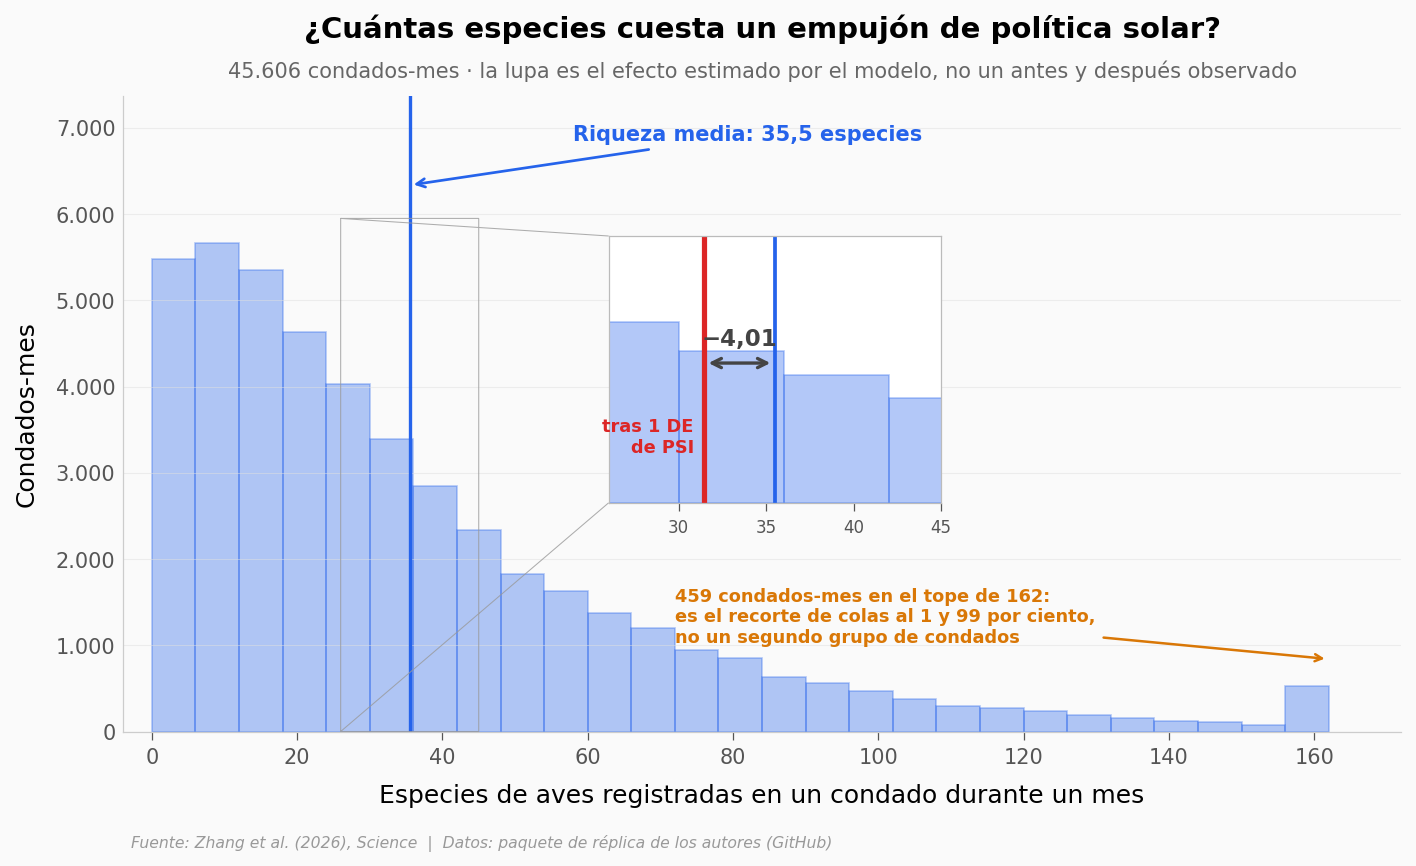

Riqueza:       β -0.9751  EE 0.1829  p 0.0000 ***  N 45.606
Equitatividad: β +0.0018  EE 0.0007  p 0.0097 ***  N 43.958

Por cada DE de PSI (4,12 puntos): -4,01 especies, -11,3 por ciento de la riqueza media
Observaciones en el tope de 162 especies: 459 (1,01 por ciento) — recorte de colas


In [6]:
riqueza = regresion(d, 'Richness')
equitatividad = regresion(d, 'Evenness')

media_riqueza  = d.Richness.mean()
efecto_riqueza = riqueza['b'] * SD_PSI            # cambio por 1 DE de PSI
tras_efecto    = media_riqueza + efecto_riqueza
datos_hist     = d.Richness.dropna()
tope           = datos_hist.max()

fig, ax = plt.subplots(figsize=(11, 5.5))
n, bins, _ = ax.hist(datos_hist, bins=27, range=(0, 162), color=COLOR_DATOS,
                     alpha=0.35, edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.30
ax.set_ylim(0, y_max)
ax.set_xlim(-4, 172)

ax.axvline(media_riqueza, color=COLOR_DATOS, linewidth=1.6)
ax.annotate(f'Riqueza media: {media_riqueza:.1f} especies'.replace('.', ','),
            xy=(media_riqueza, y_max * 0.86), xytext=(58, y_max * 0.93),
            fontsize=10, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.3))

# El recorte de colas al 1/99 del código original apila las colas en un solo valor
apilados = int((datos_hist == tope).sum())
ax.annotate(f'{apilados} condados-mes en el tope de {tope:.0f}:\n'
            'es el recorte de colas al 1 y 99 por ciento,\nno un segundo grupo de condados',
            xy=(tope, n[-1] * 1.6), xytext=(72, y_max * 0.14),
            fontsize=8.5, color=COLOR_REFERENCIA, fontweight='bold', ha='left',
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.2))

# El efecto son 4 especies sobre un eje que llega a 162: hay que acercarse para verlo
lupa = ax.inset_axes([0.38, 0.36, 0.26, 0.42])
lupa.hist(datos_hist, bins=27, range=(0, 162), color=COLOR_DATOS,
          alpha=0.35, edgecolor=COLOR_DATOS, linewidth=0.8)
lupa.axvline(media_riqueza, color=COLOR_DATOS, linewidth=1.8)
lupa.axvline(tras_efecto, color=COLOR_ALERTA, linewidth=2.5)
lupa.set_xlim(26, 45)
lupa.set_ylim(0, n.max() * 1.05)
lupa.annotate('', xy=(tras_efecto, n.max() * 0.55), xytext=(media_riqueza, n.max() * 0.55),
              arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.6))
lupa.text((media_riqueza + tras_efecto) / 2, n.max() * 0.62,
          f'−{abs(efecto_riqueza):.2f}'.replace('.', ','),
          ha='center', fontsize=11, fontweight='bold', color='#444444')
lupa.text(tras_efecto - 0.6, n.max() * 0.20, 'tras 1 DE\nde PSI', ha='right',
          fontsize=8.5, color=COLOR_ALERTA, fontweight='bold')
lupa.set_yticks([])
lupa.tick_params(labelsize=8)
lupa.grid(visible=False)
lupa.set_facecolor('#FFFFFF')
for lado in lupa.spines.values():
    lado.set_visible(True); lado.set_color('#BBBBBB')
ax.indicate_inset_zoom(lupa, edgecolor='#999999', alpha=0.8)

ax.set_xlabel('Especies de aves registradas en un condado durante un mes')
ax.set_ylabel('Condados-mes')
ax.set_title('¿Cuántas especies cuesta un empujón de política solar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(datos_hist):,}'.replace(',', '.') +
        ' condados-mes · la lupa es el efecto estimado por el modelo, '
        'no un antes y después observado',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
coma_decimal(ax, 'y', decimales=0)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/riqueza.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Riqueza:       β {riqueza['b']:+.4f}  EE {riqueza['ee']:.4f}  "
      f"p {riqueza['p']:.4f} {riqueza['estrellas']}  N {riqueza['N']:,}".replace(',', '.'))
print(f"Equitatividad: β {equitatividad['b']:+.4f}  EE {equitatividad['ee']:.4f}  "
      f"p {equitatividad['p']:.4f} {equitatividad['estrellas']}  "
      f"N {equitatividad['N']:,}".replace(',', '.'))
print()
print(f'Por cada DE de PSI ({SD_PSI:.2f} puntos): {efecto_riqueza:+.2f} especies, '
      f'{100 * efecto_riqueza / media_riqueza:+.1f} por ciento de la riqueza media'
      .replace('.', ','))
print(f'Observaciones en el tope de {tope:.0f} especies: {apilados} '
      f'({100 * apilados / len(datos_hist):.2f} por ciento) — recorte de colas'
      .replace('.', ','))

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Donde el rigor de política sube, el índice de Shannon baja | ✅ | β −0,0125 (EE 0,0037; t −3,43; p 0,0006) con N 46.371 y 2.344 condados. Idéntico a la Tabla 1 del paper al cuarto decimal. Es un panel observacional con efectos fijos, no un experimento: nadie sorteó qué condado recibía política. |
| El efecto se concentra en condados no pobres y fuera del desierto | ⚠️ | Los coeficientes reproducen la tabla de heterogeneidad del paquete de réplica: −0,0132*** en no designados pobres frente a +0,0007 (p 0,91) en designados pobres, y −0,0165*** fuera del desierto frente a +0,0190 (p 0,11) en desierto y grava. Pero un coeficiente significativo al lado de uno que no lo es todavía no prueba que difieran, y ese contraste hay que testearlo aparte: desierto contra no desierto da +0,0355 (EE 0,0125; p 0,004) y Tres-Nortes +0,0252 (EE 0,0087; p 0,004), mientras que el de pobreza da +0,0139 (EE 0,0077; p 0,07) — ese último no se distingue de cero. Ojo también: intervalo que cruza el cero ≠ efecto nulo demostrado, y el submuestreo de desierto son 298 condados contra 2.046. |
| Le pega a las especies extendidas, no a las endémicas | ✅ | No endémicas −0,0127*** (N 46.217) frente a endémicas +0,0022 (p 0,32; N 24.581), y aquí el contraste sí se sostiene por sí solo: la diferencia entre ambas, medida dentro del mismo condado-mes, es −0,0092 (EE 0,0034; p 0,007). Reproduce la tabla de rasgos del paquete de réplica. El eje del paper es endemismo, no rareza. |
| El área foliar sube mientras la diversidad baja | ✅ | LAI +0,0039*** (EE 0,0007), NDVI −0,0609*** y luz nocturna −0,2220***. Reproduce la Tabla 2. Los autores llaman a esa combinación "enverdecimiento inferior" — término que acuñan aquí, no vocabulario previo. |
| Lo que se pierde son especies, no equilibrio | ✅ | Riqueza −0,9751*** (EE 0,1829): unas 4 especies menos por cada desviación estándar de PSI, cerca del 11 por ciento de la riqueza media. La equitatividad no baja: sube levemente (+0,0018***), unos +0,007 puntos por cada desviación estándar de PSI sobre una media de 0,80 — un efecto real pero diminuto. |
| El mecanismo es la conversión de cultivos y pastizales en suelo desarrollado | ❌ | El abstract lo afirma, pero **esa regresión no existe en el paquete de réplica** y el material suplementario de Science no es accesible. Nosotros solo reprodujimos NDVI, luz nocturna y área foliar. |
| Hay que poner salvaguardas de biodiversidad al desarrollo fotovoltaico | ⚠️ | Es la recomendación de los autores, no un resultado de los datos ni una posición del canal. La reportamos atribuida. |

> **Limitaciones.** (1) Los índices de aves salen de ciencia ciudadana: el esfuerzo de observación no es parejo entre condados ni entre meses, y los efectos fijos absorben el nivel de cada condado pero no un cambio en las ganas de salir a mirar pájaros. (2) El PSI mide rigor de política, no capacidad instalada — un condado con política estricta y ningún panel puesto cuenta igual. (3) La marca de condado pobre viene fusionada por nombre de condado en el código original, y nueve identificadores quedan con valor inconsistente por nombres repetidos entre provincias; lo dejamos así porque es lo que reproduce el N del paper. (4) Nuestros descriptivos van sobre la muestra de estimación (46.371 filas) y los del paper sobre la fusionada previa (46.528): son 157 filas de diferencia, un 0,34 por ciento. (5) Las colas de todas las variables vienen recortadas al 1 y al 99 por ciento desde el código original: por eso hay 459 condados-mes clavados en 162 especies y 466 en el Shannon máximo. Ese apilamiento es del recorte, no del campo. (6) Los cortes por subgrupo son exploratorios: entre heterogeneidad, rasgos, mecanismos y especificaciones aquí se corren unas 28 pruebas sin corrección por comparaciones múltiples. Los resultados centrales (p ≤ 0,001) aguantarían cualquier ajuste; los que se leen como "sin señal" hay que tomarlos con esa pinza. (7) Los efectos fijos controlan lo que no cambia en un condado y lo que cambia parejo en un mes, pero no algo que se mueva dentro de un condado al mismo tiempo que la política.

## Ahora tú

**1. ¿El efecto aparece de una o se demora?** El PSI de un condado en el mes *t* podría estar pegándole a las aves de tres meses después. Pista: crea un PSI rezagado con `d = d.sort_values(['id','ym']); d['PI_lag3'] = d.groupby('id')['PI'].shift(3)` y corre `regresion(d, 'ShannonBD', x='PI_lag3')`.

**2. ¿Los controles están haciendo el trabajo?** El paper reporta tres columnas: sin controles, con algunos, con todos. Pista: `regresion(d, 'ShannonBD', controles=[])` debería darte −0,0157, y `controles=['Temp','Wind','Pop','Duration','Carbon']` unos −0,0127. Si el coeficiente casi no se mueve, los controles no son los que sostienen el resultado.

**3. ¿Cuánto pesa el descarte de singletons?** Sobre `ShannonBD` no pesa nada: los CSV ya vienen sin condados de una sola observación. Donde sí actúa es en las variables con faltantes, porque al botar filas vuelven a aparecer condados solos. Pista: en `_quitar_singletons`, cambia el `while True` por un solo pase y corre `regresion(d, 'Evenness')` — mira cuántas filas quedan frente a las 43.958 originales y qué le pasa al error estándar.

In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿el resultado depende de los controles?
especificaciones = [
    ('Sin controles',      []),
    ('Clima y población',  ['Temp', 'Wind', 'Pop', 'Duration', 'Carbon']),
    ('Todos (del paper)',  CONTROLES),
]

print(f"{'Especificación':22s} {'β':>10s} {'EE':>9s} {'p':>9s}   {'N':>7s}")
print('─' * 62)
for nombre, ctrls in especificaciones:
    r = regresion(d, VARIABLE_AVES, controles=ctrls)
    print(f"{nombre:22s} {r['b']:>10.4f} {r['ee']:>9.4f} {r['p']:>9.4f} "
          f"{r['estrellas']:>3s} {r['N']:>7,}".replace(',', '.'))

print('\nEl paper reporta −0,0157 / −0,0127 / −0,0125 en esas tres columnas.')
print('El coeficiente se mueve poco: los controles no son los que sostienen el resultado.')

Especificación                  β        EE         p         N
──────────────────────────────────────────────────────────────
Sin controles             -0.0157    0.0037    0.0000 ***  46.371
Clima y población         -0.0127    0.0036    0.0005 ***  46.371


Todos (del paper)         -0.0125    0.0037    0.0006 ***  46.371

El paper reporta −0,0157 / −0,0127 / −0,0125 en esas tres columnas.
El coeficiente se mueve poco: los controles no son los que sostienen el resultado.


---

## Cómo reproducir esto

Todo lo de arriba sale de dos CSV (menos de 10 MB juntos) y de las treinta líneas de `regresion()` que están más arriba. No hay resultados precocinados: cada coeficiente de cada gráfica se recalcula al ejecutar el notebook, y los CSV se construyeron siguiendo el orden exacto del archivo de Stata de los autores — el relleno del PSI faltante con cero, el descarte por controles ausentes, el recorte de colas al 1 y al 99 por ciento y el descarte de singletons van en ese orden, y cambiarlo mueve los números.

Los datos y este notebook viven en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-08-20-solar-china-aves-diversidad), y el botón de Colab del principio lo abre sin instalar nada.

## Fuentes

**Paper**: [China’s solar expansion policy reduces bird diversity](https://doi.org/10.1126/science.aee0747)  
*Science, 2026-08-20 · paywall*

**Dataset canónico**: [Replication package for “China’s solar expansion policy reduces bird diversity” (Stata do-file, DATA.rar, tablas de salida)](https://github.com/jianke22/China-s-solar-expansion-policy-reduces-bird-diversity)  
*Panel de estimación, tablas de salida y do-file de Stata publicados por los autores*

*19 afirmaciones del notebook verificadas contra estas fuentes*